## Logistic Regression on Bank Dataset

dataset link - [https://www.kaggle.com/datasets/soylevbeytullah/bank-additional](https://)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df = pd.read_csv('/content/bank-additional-full[1].csv',sep = ';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Target column --> y (predict whether a customer will subscirbe to a term deposit or not)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [23]:
df.shape

(41188, 21)

In [24]:
df.duplicated().sum()

np.int64(12)

In [25]:
df.drop_duplicates()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [26]:
df.isnull().sum().sum()

np.int64(0)

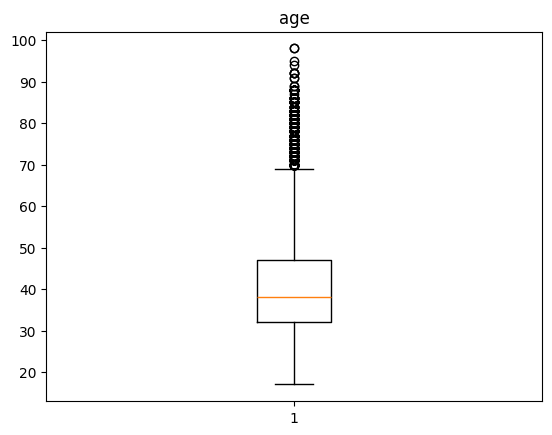

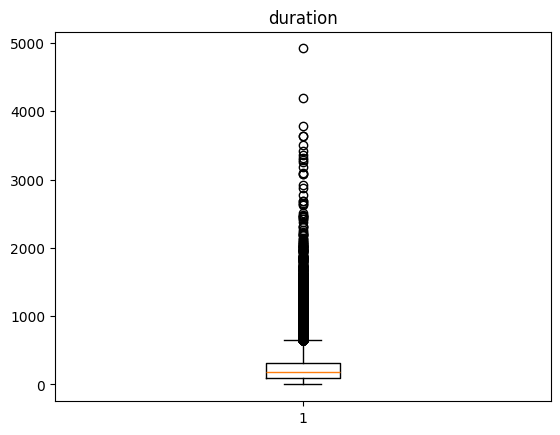

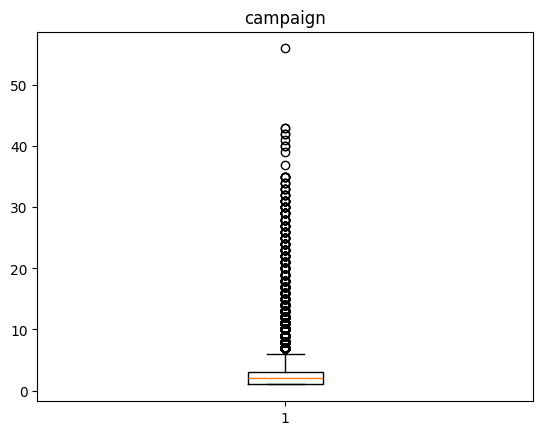

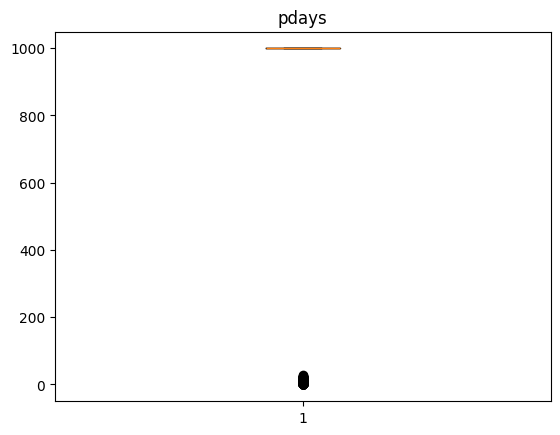

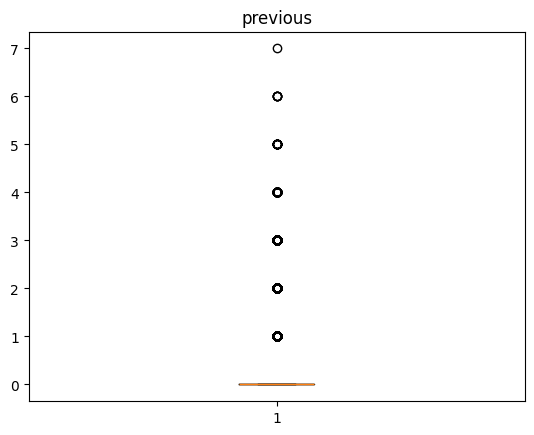

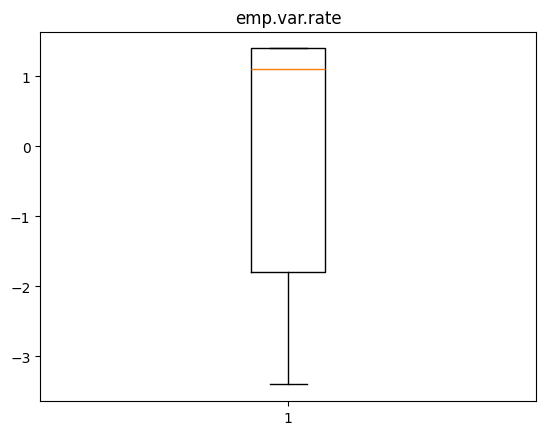

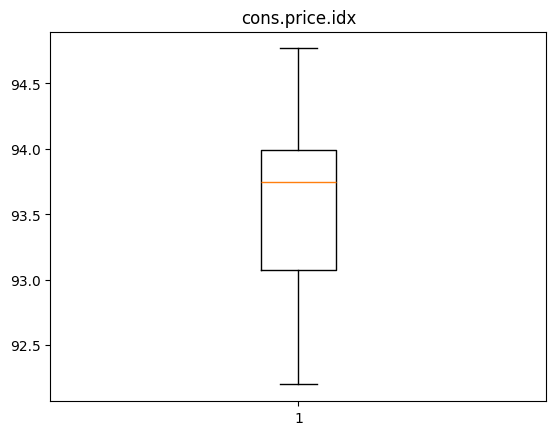

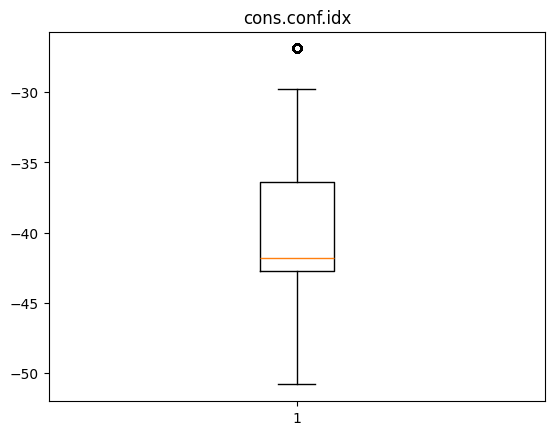

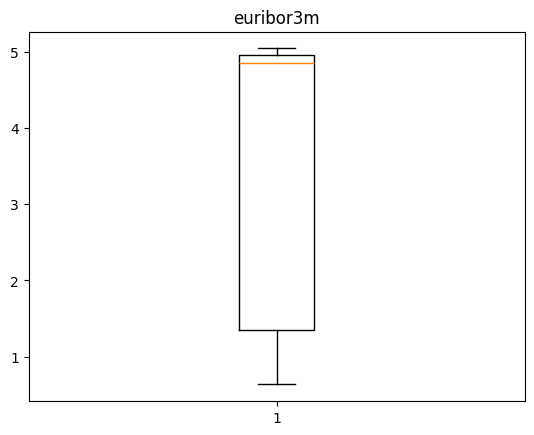

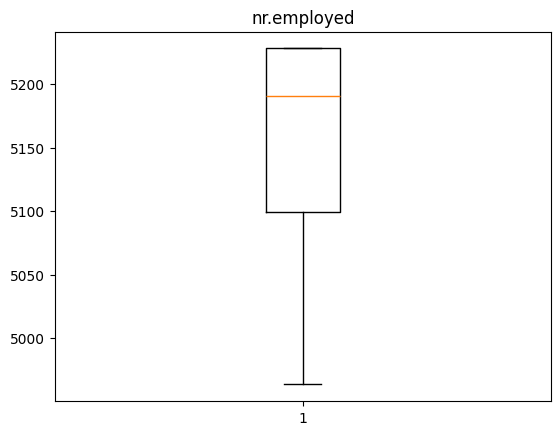

In [27]:
for col in df.columns:
  if (df[col].dtype != 'object'):
    plt.boxplot(df[col])
    plt.title(col)
    plt.show()


In [28]:
print(df['housing'].value_counts())
print(df['loan'].value_counts())
print(df['y'].value_counts())
print(df['marital'].value_counts())
print(df['month'].value_counts())
print(df['day_of_week'].value_counts())
print(df['poutcome'].value_counts())
print(df['contact'].value_counts())
print(df['default'].value_counts())

housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64
y
no     36548
yes     4640
Name: count, dtype: int64
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64
month
may    13769
jul     7174
aug     6178
jun     5318
nov     4101
apr     2632
oct      718
sep      570
mar      546
dec      182
Name: count, dtype: int64
day_of_week
thu    8623
mon    8514
wed    8134
tue    8090
fri    7827
Name: count, dtype: int64
poutcome
nonexistent    35563
failure         4252
success         1373
Name: count, dtype: int64
contact
cellular     26144
telephone    15044
Name: count, dtype: int64
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64


In [29]:
# converting object dtype to int

df['housing'] = df['housing'].replace('unknown', 'yes')
df['housing'] = df['housing'].map({'yes':1, 'no':0})

df['loan'] = df['loan'].replace('unknown', 'no')
df['loan'] = df['loan'].map({'yes':1, 'no':0})

df['y'] = df['y'].map({'yes':1, 'no':0})

df['marital'] = df['marital'].replace('unknown', 'single')
df['marital'] = df['marital'].map({'single':0, 'married':1, 'divorced':2})

month_map = {
    'mar':3, 'apr':4, 'may':5, 'jun':6, 'jul':7, 'aug':8, 'sep':9, 'oct':10, 'nov':11, 'dec':12
}
df['month'] = df['month'].map(month_map)

day_map = {
    'mon':1, 'tue':2, 'wed':3, 'thu':4, 'fri':5
}
df['day_of_week'] = df['day_of_week'].map(day_map)

# One-hot encode poutcome and contact columns
df = pd.get_dummies(df, columns=['poutcome', 'contact'],drop_first=True, dtype = int)


In [30]:
df.head()

,age,job,marital,education,default,housing,loan,month,day_of_week,duration,...,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,poutcome_nonexistent,poutcome_success,contact_telephone
0,56,housemaid,1,basic.4y,no,0,0,5,1,261,...,0,1.1,93.994,-36.4,4.857,5191.0,0,1,0,1
1,57,services,1,high.school,unknown,0,0,5,1,149,...,0,1.1,93.994,-36.4,4.857,5191.0,0,1,0,1
2,37,services,1,high.school,no,1,0,5,1,226,...,0,1.1,93.994,-36.4,4.857,5191.0,0,1,0,1
3,40,admin.,1,basic.6y,no,0,0,5,1,151,...,0,1.1,93.994,-36.4,4.857,5191.0,0,1,0,1
4,56,services,1,high.school,no,0,1,5,1,307,...,0,1.1,93.994,-36.4,4.857,5191.0,0,1,0,1


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   41188 non-null  int64  
 1   job                   41188 non-null  object 
 2   marital               41188 non-null  int64  
 3   education             41188 non-null  object 
 4   default               41188 non-null  object 
 5   housing               41188 non-null  int64  
 6   loan                  41188 non-null  int64  
 7   month                 41188 non-null  int64  
 8   day_of_week           41188 non-null  int64  
 9   duration              41188 non-null  int64  
 10  campaign              41188 non-null  int64  
 11  pdays                 41188 non-null  int64  
 12  previous              41188 non-null  int64  
 13  emp.var.rate          41188 non-null  float64
 14  cons.price.idx        41188 non-null  float64
 15  cons.conf.idx      

In [32]:
# VIF to reduce columns and multicollinearity and labelencoding for object cols

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.columns:
  if df[col].dtype == 'object':
    df[col] = le.fit_transform(df[col])


from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.drop('y',axis = 1)
Y = df['y']

vif = pd.DataFrame()
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
display(vif)

,Features,VIF
0,age,19.786865
1,job,2.120082
2,marital,3.466502
3,education,4.463571
4,default,1.410531
5,housing,2.232551
6,loan,1.181177
7,month,22.438795
8,day_of_week,5.471972
9,duration,2.018715


In [33]:
X = df.drop(columns=['y', 'nr.employed',])
Y = df['y']

vif = pd.DataFrame()
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
display(vif)

,Features,VIF
0,age,19.780549
1,job,2.120075
2,marital,3.465870
3,education,4.459499
4,default,1.409594
5,housing,2.231703
6,loan,1.181107
7,month,20.904576
8,day_of_week,5.464458
9,duration,2.012743


In [34]:
X = df.drop(columns=['y', 'nr.employed','cons.price.idx'])
Y = df['y']

vif = pd.DataFrame()
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
display(vif)

,Features,VIF
0,age,19.127625
1,job,2.113563
2,marital,3.462988
3,education,4.406888
4,default,1.409549
5,housing,2.230061
6,loan,1.180842
7,month,20.893504
8,day_of_week,5.433417
9,duration,2.006062


In [35]:
X = df.drop(columns=['y', 'nr.employed','cons.price.idx','pdays'])
Y = df['y']

vif = pd.DataFrame()
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
display(vif)

,Features,VIF
0,age,18.424008
1,job,2.109163
2,marital,3.461016
3,education,4.348330
4,default,1.409471
5,housing,2.226825
6,loan,1.180752
7,month,20.888931
8,day_of_week,5.394961
9,duration,2.004250


In [36]:
X = df.drop(columns=['y', 'nr.employed','cons.price.idx','pdays','euribor3m'])
Y = df['y']

vif = pd.DataFrame()
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
display(vif)

,Features,VIF
0,age,17.856827
1,job,2.107377
2,marital,3.459694
3,education,4.305839
4,default,1.406734
5,housing,2.224048
6,loan,1.180488
7,month,12.192210
8,day_of_week,5.356840
9,duration,2.000492


In [37]:
X = df.drop(columns=['y', 'nr.employed','cons.price.idx','pdays','euribor3m','cons.conf.idx'])
Y = df['y']

vif = pd.DataFrame()
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
display(vif)

,Features,VIF
0,age,16.760673
1,job,2.103640
2,marital,3.455875
3,education,4.243472
4,default,1.403084
5,housing,2.195659
6,loan,1.177829
7,month,12.055464
8,day_of_week,5.125684
9,duration,1.979794


In [38]:
X = df.drop(columns=['y', 'nr.employed','cons.price.idx','pdays','euribor3m','cons.conf.idx','poutcome_nonexistent'])
Y = df['y']

vif = pd.DataFrame()
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
display(vif)

,Features,VIF
0,age,14.219465
1,job,2.091329
2,marital,3.455418
3,education,4.052356
4,default,1.400891
5,housing,2.164499
6,loan,1.175644
7,month,10.242809
8,day_of_week,4.876188
9,duration,1.938911
